# 02. Unimodal Baseline Encoders: CBAM Visual Encoder + GRU-D Gas Encoder

In [1]:
import csv
import random
import re
import json
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint 
import torchvision.transforms.functional as TF
from sklearn.metrics import f1_score, roc_auc_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

MANIFEST = Path("~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv").expanduser()
ROOT     = Path("~/Desktop/Thesis/TR-6").expanduser()          
GAS_NORM = Path("~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json").expanduser()
RUNS     = Path("~/Desktop/convscript/runs").expanduser()
ENCODER_OUT = RUNS / "03_encoders_baselines"
ENCODER_OUT.mkdir(parents=True, exist_ok=True)

DEVICE = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()          else
    "cpu"
)
print(f"Device: {DEVICE}")

Device: mps


In [2]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
FRUIT_COLORS = {'Banana':'#F5C518','Carrot':'#FF6B35','Guava':'#7BC67E',
                'Indian_Gooseberry':'#9B59B6','Mango':'#FF8C00','Tomato':'#E74C3C'}
SESSION_TO_IDX = {'morning':0,'afternoon':1,'evening':2}
LABEL_TO_IDX   = {'not_spoiled':0,'spoiled':1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning':(5,11),'afternoon':(12,16),'evening':(16,19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)
NUM_FRUITS   = len(FRUIT_TO_IDX)
ABLATIONS    = ['no_cross_attn','no_dropout','no_fruit_emb','no_recon','no_session_idx','no_gas_norm']
THRESHOLDS_TO_SWEEP = [t/100 for t in range(10, 91)]

SUBSETS = [
    {'name':'RGB only',       'rgb':True,  'ir':False,'gas':False},
    {'name':'IR only',        'rgb':False, 'ir':True, 'gas':False},
    {'name':'Gas only',       'rgb':False, 'ir':False,'gas':True},
    {'name':'RGB + IR',       'rgb':True,  'ir':True, 'gas':False},
    {'name':'RGB + Gas',      'rgb':True,  'ir':False,'gas':True},
    {'name':'IR + Gas',       'rgb':False, 'ir':True, 'gas':True},
    {'name':'All modalities', 'rgb':True,  'ir':True, 'gas':True},
]
N_AVAILABLE = {'RGB only':1,'IR only':1,'Gas only':1,
               'RGB + IR':2,'RGB + Gas':2,'IR + Gas':2,'All modalities':3}

def safe_float(val, default=0.0):
    try: return float(val)
    except: return default

def hour_to_session(hour):
    for name,(lo,hi) in SESSION_HOUR_BUCKETS.items():
        if lo<=hour<hi: return name
    return 'unknown'

def find_ir_folder(base):
    for name in ['IR_fusion_images','IR_Fusion_images','ir_fusion_images']:
        p=base/name
        if p.exists(): return p
    return base/'IR_fusion_images'

def group_images_by_session(folder, pattern):
    result=defaultdict(lambda:defaultdict(list))
    if not folder.exists(): return {}
    for f in sorted(folder.iterdir()):
        m=pattern.search(f.name)
        if not m: continue
        session=hour_to_session(int(m.group(2)[:2]))
        if session!='unknown': result[m.group(1)][session].append(f)
    return dict(result)

print('Constants ready.')

Constants ready.


## 1. Data

In [3]:
def get_rgb_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

In [4]:
class TrimodalDataset(Dataset):
    def __init__(self,manifest_path,root,train=True,modality_dropout_prob=0.3,
                 exclude_flagged=True,split=None,gas_norm_stats_path=None,
                 cache_images=True,shared_pixel_cache=None,gas_only=False):
        self.root=Path(root);self.train=train;self.modality_dropout_prob=modality_dropout_prob
        self.rgb_transform=get_rgb_transform(train);self.ir_transform=get_ir_transform(train)
        self.gas_norm_stats=None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f: self.gas_norm_stats=json.load(f)['stats']
            print(f'Gas norm stats loaded from {gas_norm_stats_path}')
        with open(manifest_path,newline='') as f: all_rows=list(csv.DictReader(f))
        if exclude_flagged: all_rows=[r for r in all_rows if r.get('exclude','').strip().lower()!='true']
        if split: all_rows=[r for r in all_rows if r.get('split','').strip().lower()==split.lower()]
        self.samples=[];self._build_samples(all_rows)
        self.gas_only=gas_only;self._image_cache={}
        if not gas_only: self._build_image_index()
        self._pixel_cache={}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache=shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).',flush=True)
            elif cache_images: self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions ({"train" if train else "val/test"}, split={split})')

    def _build_samples(self,rows):
        for row in rows:
            fruit=row['fruit'];label=row['label'];date_str=row['actual_date']
            global_day=int(row['corrected_day_index'])
            days_until=safe_float(row.get('days_until_spoilage',''),default=-1.0)
            for session in ['morning','afternoon','evening']:
                si=SESSION_TO_IDX[session]
                ir_avail=safe_float(row.get(f'ir_{session}_count',0))>0
                ir_tmin=safe_float(row.get(f'ir_{session}_tmin',''),0.0)
                ir_tmax=safe_float(row.get(f'ir_{session}_tmax',''),0.0)
                ir_trange=safe_float(row.get(f'ir_{session}_trange',''),0.0)
                srgb_avail=safe_float(row.get(f'srgb_{session}_count',0))>0
                gas_avail=row.get(f'methane_{session}_present','').strip().upper()=='TRUE'
                mean_ppm=safe_float(row.get(f'methane_{session}_ppm',''),0.0)
                std_ppm=safe_float(row.get(f'methane_{session}_std',''),0.0)
                left_ppm=safe_float(row.get(f'methane_{session}_left',''),0.0)
                right_ppm=safe_float(row.get(f'methane_{session}_right',''),0.0)
                if not ir_avail and not srgb_avail and not gas_avail: continue
                self.samples.append({'fruit':fruit,'label':label,'actual_date':date_str,
                    'corrected_day_index':global_day,'session':session,'session_idx':si,
                    'fruit_idx':FRUIT_TO_IDX.get(fruit,0),'label_idx':LABEL_TO_IDX.get(label,0),
                    'days_until_spoilage':days_until,'ir_tmin':ir_tmin,'ir_tmax':ir_tmax,
                    'ir_trange':ir_trange,'gas_mean':mean_ppm,'gas_std':std_ppm,
                    'gas_left':left_ppm,'gas_right':right_ppm,'gas_asym':abs(left_ppm-right_ppm),
                    'rgb_available':srgb_avail,'ir_available':ir_avail,'gas_available':gas_avail})

    def _build_image_index(self):
        label_map={'not_spoiled':'Not_spoiled','spoiled':'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk,lf in label_map.items():
                base=self.root/'Classified'/fruit/lf
                for d,ss in group_images_by_session(base/'sRGB_images',SRGB_PATTERN).items():
                    for s,ps in ss.items():
                        self._image_cache.setdefault((fruit,lk,d,s),{'rgb':[],'ir':[]})['rgb']=ps
                for d,ss in group_images_by_session(find_ir_folder(base),IR_PATTERN).items():
                    for s,ps in ss.items():
                        self._image_cache.setdefault((fruit,lk,d,s),{'rgb':[],'ir':[]})['ir']=ps
        banana_ir=group_images_by_session(find_ir_folder(self.root/'Normal'/'Banana'),IR_PATTERN)
        spoiled_dates={date for (fr,lb,date,_) in self._image_cache if fr=='Banana' and lb=='spoiled'}
        for d,ss in banana_ir.items():
            if d in spoiled_dates:
                for s,ps in ss.items():
                    key=('Banana','spoiled',d,s)
                    self._image_cache.setdefault(key,{'rgb':[],'ir':[]})
                    if not self._image_cache[key].get('ir'): self._image_cache[key]['ir']=ps

    def _load_cached(self,path,transform):
        cached=self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1,2,0).numpy()))
        return load_image(path,transform)

    def _warmup_pixel_cache(self):
        all_paths=set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb',[]));all_paths.update(v.get('ir',[]))
        total=len(all_paths)
        print(f'  Warming up image cache: {total} images...',flush=True)
        for i,path in enumerate(all_paths):
            if str(path) in self._pixel_cache: continue
            try:
                img=self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)]=torch.from_numpy(np.array(img)).permute(2,0,1)
            except: pass
            if (i+1)%500==0 or (i+1)==total:
                mb=sum(t.nbytes for t in self._pixel_cache.values())/(1024**2)
                print(f'  {i+1}/{total} cached  ({mb:.0f} MB used)',flush=True)
        print(f'  Cache ready. {len(self._pixel_cache)} images in RAM.',flush=True)

    def _normalize_gas(self,fruit,session,mean_ppm,std_ppm,left_ppm,right_ppm):
        if self.gas_norm_stats is None: return mean_ppm,std_ppm,left_ppm,right_ppm
        s=self.gas_norm_stats.get(fruit,{}).get(session,{})
        def norm(val,key): st=s.get(key,{'mean':0.,'std':1.}); return (val-st['mean'])/st['std']
        return norm(mean_ppm,'mean_ppm'),norm(std_ppm,'std_ppm'),norm(left_ppm,'left_ppm'),norm(right_ppm,'right_ppm')

    def _apply_dropout(self,rgb_avail,ir_avail,gas_avail):
        if not self.train: return rgb_avail,ir_avail,gas_avail
        while True:
            r=rgb_avail and (random.random()>self.modality_dropout_prob)
            i=ir_avail  and (random.random()>self.modality_dropout_prob)
            g=gas_avail and (random.random()>self.modality_dropout_prob)
            if r or i or g: return r,i,g

    def __len__(self): return len(self.samples)

    def __getitem__(self,idx):
        s=self.samples[idx]
        fruit=s['fruit'];label=s['label'];date_str=s['actual_date']
        session=s['session'];si=s['session_idx']
        rgb_avail,ir_avail,gas_avail=self._apply_dropout(s['rgb_available'],s['ir_available'],s['gas_available'])
        cached=self._image_cache.get((fruit,label,date_str,session),{'rgb':[],'ir':[]})
        if not self.gas_only and rgb_avail and cached['rgb']:
            rgb_tensors=torch.stack([self._load_cached(p,self.rgb_transform) for p in cached['rgb']])
        else: rgb_avail=False;rgb_tensors=torch.zeros(1,3,IMAGE_SIZE,IMAGE_SIZE)
        if not self.gas_only and ir_avail and cached['ir']:
            ir_tensors=torch.stack([self._load_cached(p,self.ir_transform) for p in cached['ir']])
        else: ir_avail=False;ir_tensors=torch.zeros(1,3,IMAGE_SIZE,IMAGE_SIZE)
        ir_scalars=torch.tensor([s['ir_tmin'],s['ir_tmax'],s['ir_trange']],dtype=torch.float32) if ir_avail else torch.zeros(3)
        if gas_avail:
            m,sd,l,r=self._normalize_gas(fruit,session,s['gas_mean'],s['gas_std'],s['gas_left'],s['gas_right'])
            gas=torch.tensor([m,sd,l,r,abs(l-r),float(si)/2.],dtype=torch.float32)
        else: gas=torch.zeros(6)
        return {'rgb_images':rgb_tensors,'ir_images':ir_tensors,'ir_scalars':ir_scalars,'gas':gas,
                'rgb_available':torch.tensor(rgb_avail,dtype=torch.bool),
                'ir_available':torch.tensor(ir_avail,dtype=torch.bool),
                'gas_available':torch.tensor(gas_avail,dtype=torch.bool),
                'fruit_idx':torch.tensor(s['fruit_idx'],dtype=torch.long),
                'session_idx':torch.tensor(si,dtype=torch.long),
                'label':torch.tensor(s['label_idx'],dtype=torch.long),
                'days_until_spoilage':torch.tensor(s['days_until_spoilage'],dtype=torch.float32),
                'fruit':fruit,'actual_date':date_str,'corrected_day_index':s['corrected_day_index']}


class NoSessionIdxDataset(TrimodalDataset):
    def __getitem__(self,idx):
        item=super().__getitem__(idx)
        gas=item['gas'].clone(); gas[5]=0.0; item['gas']=gas
        return item

class NoGasNormDataset(TrimodalDataset):
    def __getitem__(self,idx):
        saved=self.gas_norm_stats; self.gas_norm_stats=None
        item=super().__getitem__(idx); self.gas_norm_stats=saved
        return item


def trimodal_collate(batch):
    return {'rgb_images':[s['rgb_images'] for s in batch],'ir_images':[s['ir_images'] for s in batch],
            'ir_scalars':torch.stack([s['ir_scalars'] for s in batch]),
            'gas':torch.stack([s['gas'] for s in batch]),
            'rgb_available':torch.stack([s['rgb_available'] for s in batch]),
            'ir_available':torch.stack([s['ir_available'] for s in batch]),
            'gas_available':torch.stack([s['gas_available'] for s in batch]),
            'fruit_idx':torch.stack([s['fruit_idx'] for s in batch]),
            'session_idx':torch.stack([s['session_idx'] for s in batch]),
            'label':torch.stack([s['label'] for s in batch]),
            'days_until_spoilage':torch.stack([s['days_until_spoilage'] for s in batch]),
            'fruit':[s['fruit'] for s in batch],'actual_date':[s['actual_date'] for s in batch],
            'corrected_day_index':[s['corrected_day_index'] for s in batch]}

print('Dataset ready.')


Dataset ready.


In [5]:
class DayLevelSequenceDataset(Dataset):


    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(
            manifest_path, root, train=False, modality_dropout_prob=0.0,
            split=split, gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
            shared_pixel_cache=shared_pixel_cache,
        )
        self._pixel_cache = base._pixel_cache  # exposed so a val/second dataset can reuse it
        print(f"DayLevelSequenceDataset ({split}): wrapping {len(base)} sessions")

        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)

        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))

            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]

            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)

            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"],
                "label": sessions[0]["label"],
                "days_until": sessions[0]["days_until_spoilage"],
            })

        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})

        n_days_total = sum(len(t["days"]) for t in self.trajectories)
        print(f"  {len(self.trajectories)} trajectories, {n_days_total} total day-entries "
              f"(avg {n_days_total/max(len(self.trajectories),1):.1f} days/trajectory)")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir  = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)

        rgb_seq   = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq    = torch.stack([d["ir_img"]  if d["ir_img"]  is not None else blank_ir  for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail  = torch.tensor([d["ir_img"]  is not None for d in traj], dtype=torch.bool)
        gas_seq   = torch.stack([d["gas_vec"] for d in traj])
        gas_mask  = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)

        return {
            "rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
            "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
            "days_until": traj[-1]["days_until"],
        }


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)

    rgb  = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir   = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail  = torch.zeros(B, max_T, dtype=torch.bool)
    gas  = torch.zeros(B, max_T, 6)
    gas_mask  = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask  = torch.ones(B, max_T, dtype=torch.bool)   # True = PAD
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label     = torch.zeros(B, dtype=torch.long)
    days_until = torch.zeros(B, dtype=torch.float32)

    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]

    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until}


## 2. CBAM

In [6]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        )

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return torch.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        return torch.sigmoid(self.conv(combined))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        ca = self.channel_attn(x)
        x = x * ca
        sa = self.spatial_attn(x)
        x = x * sa
        return x, sa


## 3. CBAM Visual Encoder

In [7]:
def _infer_feature_dim(backbone, img_size=224):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str = "convnext_tiny"):
    """Toggleable: convnext_tiny is the chosen model's RGB backbone; efficientnet_b0 is
    the chosen model's actual IR backbone (see model description) -- both are supported
    here so a unimodal IR-only run can be trained on either for direct comparison."""
    if name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        backbone = base.features
    elif name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = base.features
    else:
        raise ValueError(f"Unsupported backbone_name: {name!r} -- expected 'convnext_tiny' or 'efficientnet_b0'")
    feat_dim = _infer_feature_dim(backbone)
    return backbone, feat_dim


class CBAMVisualEncoder(nn.Module):
    def __init__(self, backbone_name="convnext_tiny", num_classes=2, dropout=0.3,
                 freeze_backbone=True, cbam_reduction=16, chunk_size=8):
        super().__init__()
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        self.cbam = CBAM(self.feature_dim, reduction=cbam_reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()
        self.dropout = nn.Dropout(p=dropout)
        self.cls_head = nn.Sequential(
            nn.Linear(self.feature_dim, 256), nn.ReLU(), nn.Dropout(p=dropout), nn.Linear(256, num_classes),
        )
        self.reg_head = nn.Sequential(
            nn.Linear(self.feature_dim, 256), nn.ReLU(), nn.Dropout(p=dropout), nn.Linear(256, 1), nn.ReLU(),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        children = list(self.backbone.children())
        for child in children[-n:]:
            for p in child.parameters():
                p.requires_grad = True
        n_trainable = sum(p.requires_grad for p in self.backbone.parameters())
        print(f"  [{self.backbone_name}] Unfroze last {n} blocks -- {n_trainable} params trainable")

    def encode_frame(self, x):
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        if needs_ckpt:
            feat_map = checkpoint(self.backbone, x, use_reentrant=False)
        else:
            feat_map = self.backbone(x)
        feat_map, attn_map = self.cbam(feat_map)
        pooled = self.pool(feat_map).flatten(1)
        return pooled, attn_map

    def forward(self, seq: torch.Tensor, avail: torch.Tensor, return_attn: bool = False):
        """seq: (B, T, 3, H, W); avail: (B, T) bool -- True if that day's frame is real."""
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)

        feats_list, attn_list = [], []
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            f, a = self.encode_frame(chunk)
            feats_list.append(f)
            if return_attn:
                attn_list.append(a)
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)

        mask = avail.float().unsqueeze(-1)             # (B, T, 1)
        denom = mask.sum(dim=1).clamp(min=1.0)          # (B, 1)
        traj_feat = (feats * mask).sum(dim=1) / denom   # masked mean across available days

        traj_feat = self.dropout(traj_feat)
        cls_logits = self.cls_head(traj_feat)
        reg_output = self.reg_head(traj_feat)

        if return_attn:
            Hp, Wp = attn_list[0].shape[-2:]
            attn_maps = torch.cat(attn_list, dim=0).view(B, T, 1, Hp, Wp)
            return traj_feat, cls_logits, reg_output, attn_maps
        return traj_feat, cls_logits, reg_output

In [8]:
class CBAMVisualEncoder(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", num_classes=2, dropout=0.3,
                 freeze_backbone=True, cbam_reduction=16, chunk_size=8):
        super().__init__()
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        self.cbam = CBAM(self.feature_dim, reduction=cbam_reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()
        self.dropout = nn.Dropout(p=dropout)
        self.cls_head = nn.Sequential(
            nn.Linear(self.feature_dim, 256), nn.ReLU(), nn.Dropout(p=dropout), nn.Linear(256, num_classes),
        )
        self.reg_head = nn.Sequential(
            nn.Linear(self.feature_dim, 256), nn.ReLU(), nn.Dropout(p=dropout), nn.Linear(256, 1), nn.ReLU(),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        children = list(self.backbone.children())
        for child in children[-n:]:
            for p in child.parameters():
                p.requires_grad = True
        n_trainable = sum(p.requires_grad for p in self.backbone.parameters())
        print(f"  [{self.backbone_name}] Unfroze last {n} blocks -- {n_trainable} params trainable")

    def encode_frame(self, x):
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        if needs_ckpt:
            feat_map = checkpoint(self.backbone, x, use_reentrant=False)
        else:
            feat_map = self.backbone(x)
        feat_map, attn_map = self.cbam(feat_map)
        pooled = self.pool(feat_map).flatten(1)
        return pooled, attn_map

    def forward(self, seq: torch.Tensor, avail: torch.Tensor, return_attn: bool = False):
        """seq: (B, T, 3, H, W); avail: (B, T) bool -- True if that day's frame is real."""
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)

        feats_list, attn_list = [], []
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            f, a = self.encode_frame(chunk)
            feats_list.append(f)
            if return_attn:
                attn_list.append(a)
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)

        mask = avail.float().unsqueeze(-1)             # (B, T, 1)
        denom = mask.sum(dim=1).clamp(min=1.0)          # (B, 1)
        traj_feat = (feats * mask).sum(dim=1) / denom   # masked mean across available days

        traj_feat = self.dropout(traj_feat)
        cls_logits = self.cls_head(traj_feat)
        reg_output = self.reg_head(traj_feat)

        if return_attn:
            Hp, Wp = attn_list[0].shape[-2:]
            attn_maps = torch.cat(attn_list, dim=0).view(B, T, 1, Hp, Wp)
            return traj_feat, cls_logits, reg_output, attn_maps
        return traj_feat, cls_logits, reg_output


## 4. GRU-D Gas Encoder

In [9]:
class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))

        self.W_gamma_x = nn.Linear(1, input_dim)    
        self.W_gamma_h = nn.Linear(1, hidden_dim)  
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)  

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        """
        x_t:     (B, input_dim) raw value this step (garbage if m_t=0)
        m_t:     (B, input_dim) observation mask, 1=observed
        delta_t: (B, 1) time since last gas observation
        x_last:  (B, input_dim) last actually-observed gas vector, carried forward
        h_prev:  (B, hidden_dim)
        """
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))     # (B, input_dim)
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)

        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))     # (B, hidden_dim)
        h_decayed = gamma_h * h_prev

        gru_input = torch.cat([x_hat, m_t], dim=-1)
        h_t = self.gru_cell(gru_input, h_decayed)
        return h_t, x_hat


class GasGRUDEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_classes=2, dropout=0.3, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)
        self.dropout = nn.Dropout(p=dropout)
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(p=dropout), nn.Linear(64, num_classes),
        )
        self.reg_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(p=dropout), nn.Linear(64, 1), nn.ReLU(),
        )

    def forward(self, gas_seq: torch.Tensor, gas_mask: torch.Tensor,
                gas_delta: torch.Tensor, pad_mask: torch.Tensor):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)

        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)  

            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h            
            x_last = torch.where(m_t.bool(), x_t, x_last)

        traj_feat = self.dropout(h)
        cls_logits = self.cls_head(traj_feat)
        reg_output = self.reg_head(traj_feat)
        return traj_feat, cls_logits, reg_output


## Augmentation (Flip, Rotation)

In [10]:
class OfflineAugmentedDayLevelSequenceDataset(Dataset):
    def __init__(self, base_dataset, transform_type, n_copies=1):
        assert transform_type in ("flip_only", "rotation_only",
                                  "brightness_contrast_only", "flip_rotation")
        self.base = base_dataset
        self.transform_type = transform_type
        self.n_copies = n_copies

        self.index_map = []  
        for traj_idx in range(len(base_dataset)):
            self.index_map.append((traj_idx, 0))
            for copy_id in range(1, n_copies + 1):
                self.index_map.append((traj_idx, copy_id))

        self.trajectories = [base_dataset.trajectories[traj_idx] for traj_idx, _ in self.index_map]

        n_orig = len(base_dataset)
        print(f"OfflineAugmentedDayLevelSequenceDataset ({transform_type}, n_copies={n_copies}): "
             f"{n_orig} original trajectories -> {len(self)} total ({n_copies}x duplication)")

    def __len__(self):
        return len(self.index_map)

    def _augment_image(self, img, seed, is_rgb):
        g = torch.Generator().manual_seed(seed)
        out = img
        if self.transform_type in ("flip_only", "flip_rotation"):
            out = torch.flip(out, dims=[-1])  
        if self.transform_type in ("rotation_only", "flip_rotation"):
            angle = (torch.rand(1, generator=g).item() * 30.0) - 15.0  
            out = TF.rotate(out, angle)
        if is_rgb and self.transform_type == "brightness_contrast_only":
            b_factor = 0.8 + torch.rand(1, generator=g).item() * 0.4  
            c_factor = 0.8 + torch.rand(1, generator=g).item() * 0.4
            out = TF.adjust_brightness(out, b_factor)
            out = TF.adjust_contrast(out, c_factor)
        return out

    def __getitem__(self, idx):
        traj_idx, copy_id = self.index_map[idx]
        item = self.base[traj_idx]
        if copy_id == 0:
            return item  

        seed_base = traj_idx * 10_000 + copy_id * 100
        item = dict(item) 
        item["rgb_seq"] = torch.stack([
            self._augment_image(item["rgb_seq"][t], seed_base + t, is_rgb=True)
            for t in range(item["rgb_seq"].shape[0])
        ])
        item["ir_seq"] = torch.stack([
            self._augment_image(item["ir_seq"][t], seed_base + t, is_rgb=False)
            for t in range(item["ir_seq"].shape[0])
        ])
        return item

print("OfflineAugmentedDayLevelSequenceDataset ready.")

OfflineAugmentedDayLevelSequenceDataset ready.


## 5. Training utilities

In [11]:
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


def build_weighted_sampler(dataset):
    labels = [int(t["label"]) for t in dataset.trajectories]
    n_total = len(labels); n_spoiled = sum(labels); n_fresh = n_total - n_spoiled
    n_spoiled = max(n_spoiled, 1); n_fresh = max(n_fresh, 1)
    w_spoiled = n_total / (2 * n_spoiled); w_fresh = n_total / (2 * n_fresh)
    weights = [w_spoiled if l == 1 else w_fresh for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=n_total, replacement=True)


def get_cfg(encoder_type="rgb"):
    base = {
        "epochs": 30, "batch_size": 4, "lr": 1e-4, "lr_finetune": 1e-5, "weight_decay": 1e-4,
        "dropout": 0.3, "cls_weight": 1.0, "reg_weight": 0.5,
        "cls_class_weights": [1.0, 2.3], "device": DEVICE,
    }
    if encoder_type == "gas":
        base.update({"lr": 1e-3, "batch_size": 8})   # GRU-D has no pretrained backbone to fine-tune gently
    return base


def compute_loss(cls_logits, reg_output, labels, days, cfg, device):
    class_weights = torch.tensor(cfg["cls_class_weights"], device=device)
    cls_loss = nn.CrossEntropyLoss(weight=class_weights)(cls_logits, labels)
    reg_loss = nn.MSELoss()(reg_output.squeeze(1), days)
    return cfg["cls_weight"] * cls_loss + cfg["reg_weight"] * reg_loss


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    return {"f1": round(f1, 4), "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4)}


def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def forward_model(model, batch, device, encoder_type):
    if encoder_type in ("rgb", "ir"):
        seq   = batch["rgb_seq"].to(device)   if encoder_type == "rgb" else batch["ir_seq"].to(device)
        avail = batch["rgb_avail"].to(device) if encoder_type == "rgb" else batch["ir_avail"].to(device)
        return model(seq, avail)
    elif encoder_type == "gas":
        return model(batch["gas_seq"].to(device), batch["gas_mask"].to(device),
                      batch["gas_delta"].to(device), batch["pad_mask"].to(device))
    raise ValueError(encoder_type)


def run_epoch(model, loader, optimizer, cfg, encoder_type, train=True):
    model.train() if train else model.eval()
    device = cfg["device"]
    total_loss = 0.0
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            labels = batch["label"].to(device)
            days   = batch["days_until"].to(device)

            _, cls_logits, reg_output = forward_model(model, batch, device, encoder_type)
            loss = compute_loss(cls_logits, reg_output, labels, days, cfg, device)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            probs = torch.softmax(cls_logits, dim=1).detach().cpu().numpy()
            all_labels.extend(labels.cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(days.cpu().numpy().tolist())
            all_days_pred.extend(reg_output.squeeze(1).detach().cpu().numpy().tolist())

    all_probs_arr = np.array(all_probs)
    if train:
        all_preds = all_probs_arr.argmax(axis=1).tolist()
        threshold_used = 0.5
    else:
        threshold_used, _ = calibrate_threshold(all_probs_arr[:, 1].tolist(), all_labels)
        all_preds = (all_probs_arr[:, 1] >= threshold_used).astype(int).tolist()

    metrics = compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred)
    metrics["loss"] = round(total_loss / max(len(loader), 1), 4)
    metrics["threshold"] = threshold_used
    return metrics


def train_encoder(model, cfg, out_dir, encoder_type, unfreeze_fn=None,
                  augment_transform=None, n_copies=1, train_ds=None, val_ds=None):
    """train_ds/val_ds: pass already-built datasets (e.g. SHARED_TRAIN_DS/SHARED_VAL_DS)
    to skip rebuilding the manifest + re-warming the image pixel cache on every call --
    the pixel cache alone takes real time to warm (10983 images) and doesn't change
    between RGB/IR/gas runs, so rebuilding it per-encoder is pure wasted time. Falls
    back to building fresh ones if not provided, so this stays backward-compatible."""
    device = cfg["device"]
    model = model.to(device)
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    print(f"Device: {device}  |  Output: {out_dir}")

    if train_ds is None:
        print("  No train_ds passed in -- building fresh (this will re-warm the pixel cache).")
        train_ds = DayLevelSequenceDataset(split="train")
    else:
        print(f"  Reusing already-loaded train_ds ({len(train_ds)} trajectories, "
              f"{len(train_ds._pixel_cache)} images already cached) -- skipping reload.")
    if val_ds is None:
        print("  No val_ds passed in -- building fresh.")
        val_ds = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds._pixel_cache)
    else:
        print(f"  Reusing already-loaded val_ds ({len(val_ds)} trajectories) -- skipping reload.")

    if augment_transform is not None and encoder_type in ("rgb", "ir"):
        aug_ds = OfflineAugmentedDayLevelSequenceDataset(train_ds, transform_type=augment_transform, n_copies=n_copies)
        sampler = build_weighted_sampler(aug_ds)
        train_loader = DataLoader(aug_ds, batch_size=cfg["batch_size"], sampler=sampler,
                                  collate_fn=day_sequence_collate, num_workers=0)
        print(f"  Training set: {augment_transform} augmentation ({n_copies} extra copy/copies -> "
             f"{len(aug_ds)} total train trajectories from {len(train_ds)} original)")
    else:
        sampler = build_weighted_sampler(train_ds)
        train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], sampler=sampler,
                                  collate_fn=day_sequence_collate, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                              collate_fn=day_sequence_collate, num_workers=0)

    if hasattr(model, "backbone") and unfreeze_fn is not None:
        backbone_ids = {id(p) for p in model.backbone.parameters()}
        head_params  = [p for p in model.parameters() if id(p) not in backbone_ids]
        optimizer = AdamW([
            {"params": head_params, "lr": cfg["lr"]},
            {"params": model.backbone.parameters(), "lr": cfg["lr_finetune"]},
        ], weight_decay=cfg["weight_decay"])
    else:
        optimizer = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    best_f1, history = 0.0, []
    best_path = out_dir / "best_encoder.pt"

    print(f"\nTraining {encoder_type} encoder for {cfg['epochs']} epochs\n")
    for epoch in range(1, cfg["epochs"] + 1):
        if unfreeze_fn is not None:
            if epoch == 6: unfreeze_fn(model, 1)
            elif epoch == 8: unfreeze_fn(model, 2)
            elif epoch == 12:
                model.unfreeze_backbone(); print("  Full backbone unfrozen.")

        t0 = time.time()
        train_m = run_epoch(model, train_loader, optimizer, cfg, encoder_type, train=True)
        val_m   = run_epoch(model, val_loader,   optimizer, cfg, encoder_type, train=False)
        scheduler.step()
        elapsed = int(time.time() - t0)
        history.append({"epoch": epoch, "train": train_m, "val": val_m})
        print(f"Epoch {epoch:03d} ({elapsed}s) | Train F1:{train_m['f1']} AUC:{train_m['auc']} | "
              f"Val F1:{val_m['f1']} AUC:{val_m['auc']} MAE:{val_m['mae']} thr:{val_m['threshold']}")
        if val_m["f1"] > best_f1:
            best_f1 = val_m["f1"]
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "val_metrics": val_m, "cfg": cfg}, best_path)
            print(f"  \u2713 New best val F1={best_f1}")

    with open(out_dir / "history.json", "w") as f:
        json.dump({"cfg": cfg, "history": history}, f, indent=2, default=str)
    print(f"\nDone. Best val F1={best_f1}  -> {best_path}")
    return best_path


## 5b. Load Data

In [12]:
if "SHARED_TRAIN_DS" in globals() and "SHARED_VAL_DS" in globals():
    print(f"SHARED_TRAIN_DS / SHARED_VAL_DS already loaded "
          f"({len(SHARED_TRAIN_DS)} train, {len(SHARED_VAL_DS)} val trajectories, "
          f"{len(SHARED_TRAIN_DS._pixel_cache)} images cached) -- skipping reload.")
else:
    SHARED_TRAIN_DS = DayLevelSequenceDataset(split="train")
    SHARED_VAL_DS   = DayLevelSequenceDataset(split="val", shared_pixel_cache=SHARED_TRAIN_DS._pixel_cache)
    print(f"Done. {len(SHARED_TRAIN_DS)} train / {len(SHARED_VAL_DS)} val trajectories, "
          f"{len(SHARED_TRAIN_DS._pixel_cache)} images cached and ready to reuse.")

Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

## 5c. Training curve plot

In [13]:
def plot_training_curves(history_path, title):
    with open(history_path) as f:
        data = json.load(f)
    history = data["history"]
    epochs = [h["epoch"] for h in history]

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    fig.suptitle(title, fontsize=13)

    ax = axes[0, 0]
    ax.plot(epochs, [h["train"]["loss"] for h in history], label="train")
    ax.plot(epochs, [h["val"]["loss"] for h in history], label="val")
    ax.set_title("Loss"); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.plot(epochs, [h["train"]["f1"] for h in history], label="train")
    ax.plot(epochs, [h["val"]["f1"] for h in history], label="val")
    ax.set_title("F1"); ax.set_xlabel("epoch"); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    ax.plot(epochs, [h["val"]["auc"] for h in history], color="tab:green", label="val AUC")
    ax.set_title("Val AUC"); ax.set_xlabel("epoch"); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1, 1]
    ax.plot(epochs, [h["val"]["mae"] for h in history], color="tab:red", label="val MAE (days)")
    ax.set_title("Val MAE -- shelf-life regression"); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = max(history, key=lambda h: h["val"]["f1"])
    print(f"  Best epoch: {best_epoch['epoch']} -- Val F1={best_epoch['val']['f1']} "
          f"AUC={best_epoch['val']['auc']} MAE={best_epoch['val']['mae']}")

## 6. Train CBAM RGB encoder

Device: mps  |  Output: /Users/sjanani2073/Desktop/convscript/runs/03_encoders_baselines/rgb_cbam
  Reusing already-loaded train_ds (12 trajectories, 10983 images already cached) -- skipping reload.
  Reusing already-loaded val_ds (12 trajectories) -- skipping reload.
OfflineAugmentedDayLevelSequenceDataset (flip_rotation, n_copies=1): 12 original trajectories -> 24 total (1x duplication)
  Training set: flip_rotation augmentation (1 extra copy/copies -> 24 total train trajectories from 12 original)

Training rgb encoder for 30 epochs

Epoch 001 (2s) | Train F1:0.4615 AUC:0.8 | Val F1:0.6667 AUC:0.6667 MAE:2.1657 thr:0.1
  ✓ New best val F1=0.6667
Epoch 002 (2s) | Train F1:0.25 AUC:0.5385 | Val F1:0.6667 AUC:0.6389 MAE:2.1645 thr:0.1
Epoch 003 (2s) | Train F1:0.5263 AUC:0.7422 | Val F1:0.75 AUC:0.6944 MAE:2.1634 thr:0.5
  ✓ New best val F1=0.75
Epoch 004 (3s) | Train F1:0.64 AUC:0.7704 | Val F1:0.6667 AUC:0.6944 MAE:2.1625 thr:0.1
Epoch 005 (3s) | Train F1:0.7097 AUC:0.6806 | Val F1:0.

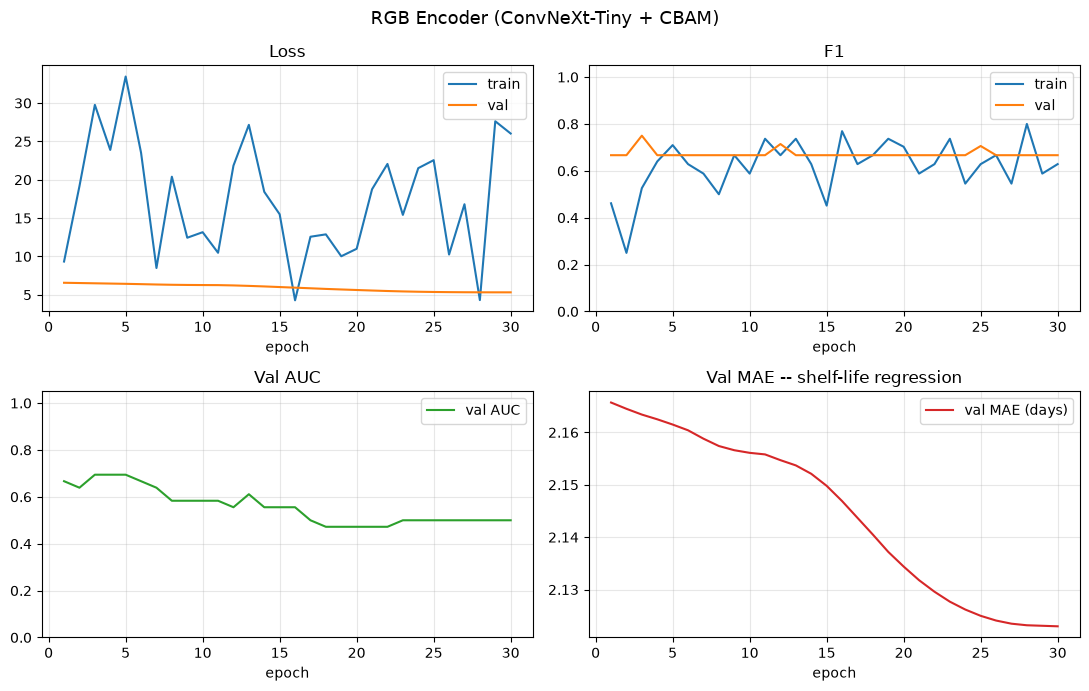

  Best epoch: 3 -- Val F1=0.75 AUC=0.6944 MAE=2.1634


In [14]:
cfg_rgb = get_cfg("rgb")
rgb_model = CBAMVisualEncoder(backbone_name="convnext_tiny", dropout=cfg_rgb["dropout"], freeze_backbone=True)
rgb_ckpt = train_encoder(
    rgb_model, cfg_rgb, ENCODER_OUT / "rgb_cbam", encoder_type="rgb",
    unfreeze_fn=lambda m, n: m.unfreeze_last_n_layers(n),
    augment_transform="flip_rotation",
    train_ds=SHARED_TRAIN_DS, val_ds=SHARED_VAL_DS,
)
plot_training_curves(ENCODER_OUT / "rgb_cbam" / "history.json", "RGB Encoder (ConvNeXt-Tiny + CBAM)")

## 7. Train CBAM IR encoder

Device: mps  |  Output: /Users/sjanani2073/Desktop/convscript/runs/03_encoders_baselines/ir_cbam_efficientnet
  Reusing already-loaded train_ds (12 trajectories, 10983 images already cached) -- skipping reload.
  Reusing already-loaded val_ds (12 trajectories) -- skipping reload.
OfflineAugmentedDayLevelSequenceDataset (flip_rotation, n_copies=1): 12 original trajectories -> 24 total (1x duplication)
  Training set: flip_rotation augmentation (1 extra copy/copies -> 24 total train trajectories from 12 original)

Training ir encoder for 30 epochs

Epoch 001 (2s) | Train F1:0.0 AUC:0.163 | Val F1:0.6667 AUC:0.5278 MAE:2.1667 thr:0.1
  ✓ New best val F1=0.6667
Epoch 002 (1s) | Train F1:0.1176 AUC:0.5469 | Val F1:0.6667 AUC:0.5 MAE:2.1644 thr:0.1
Epoch 003 (1s) | Train F1:0.4545 AUC:0.5734 | Val F1:0.6667 AUC:0.3333 MAE:2.163 thr:0.1
Epoch 004 (1s) | Train F1:0.6667 AUC:0.4792 | Val F1:0.6667 AUC:0.3889 MAE:2.1572 thr:0.1
Epoch 005 (1s) | Train F1:0.5455 AUC:0.4222 | Val F1:0.6667 AUC:0.36

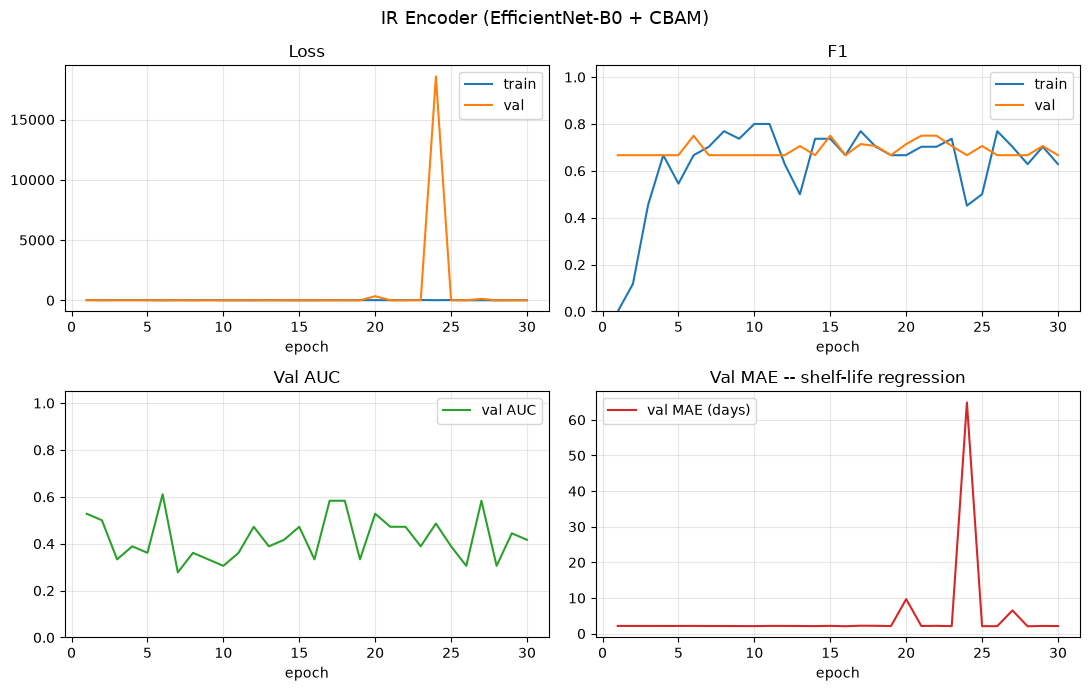

  Best epoch: 6 -- Val F1=0.75 AUC=0.6111 MAE=2.1718


In [15]:
cfg_ir = get_cfg("ir")
ir_model = CBAMVisualEncoder(backbone_name="efficientnet_b0", dropout=cfg_ir["dropout"], freeze_backbone=True)
ir_ckpt = train_encoder(
    ir_model, cfg_ir, ENCODER_OUT / "ir_cbam_efficientnet", encoder_type="ir",
    unfreeze_fn=lambda m, n: m.unfreeze_last_n_layers(n),
    augment_transform="flip_rotation",
    train_ds=SHARED_TRAIN_DS, val_ds=SHARED_VAL_DS,
)
plot_training_curves(ENCODER_OUT / "ir_cbam_efficientnet" / "history.json", "IR Encoder (EfficientNet-B0 + CBAM)")

#real

## 8. GRU-D gas encoder

Device: mps  |  Output: /Users/sjanani2073/Desktop/convscript/runs/03_encoders_baselines/gas_grud
  Reusing already-loaded train_ds (12 trajectories, 10983 images already cached) -- skipping reload.
  Reusing already-loaded val_ds (12 trajectories) -- skipping reload.

Training gas encoder for 30 epochs

Epoch 001 (0s) | Train F1:0.0 AUC:0.2593 | Val F1:0.7273 AUC:0.6667 MAE:2.1684 thr:0.49
  ✓ New best val F1=0.7273
Epoch 002 (0s) | Train F1:0.2222 AUC:0.4857 | Val F1:0.6667 AUC:0.6944 MAE:2.1665 thr:0.1
Epoch 003 (0s) | Train F1:0.2857 AUC:0.2 | Val F1:0.6667 AUC:0.7222 MAE:2.1637 thr:0.1
Epoch 004 (0s) | Train F1:0.2222 AUC:0.4167 | Val F1:0.6667 AUC:0.6667 MAE:2.1622 thr:0.1
Epoch 005 (0s) | Train F1:0.2 AUC:0.1944 | Val F1:0.6667 AUC:0.6111 MAE:2.1601 thr:0.1
Epoch 006 (0s) | Train F1:0.3333 AUC:0.4 | Val F1:0.6667 AUC:0.5 MAE:2.1579 thr:0.1
Epoch 007 (0s) | Train F1:0.6154 AUC:0.6667 | Val F1:0.6667 AUC:0.5 MAE:2.1558 thr:0.1
Epoch 008 (0s) | Train F1:0.7368 AUC:0.8571 | Val F1:0

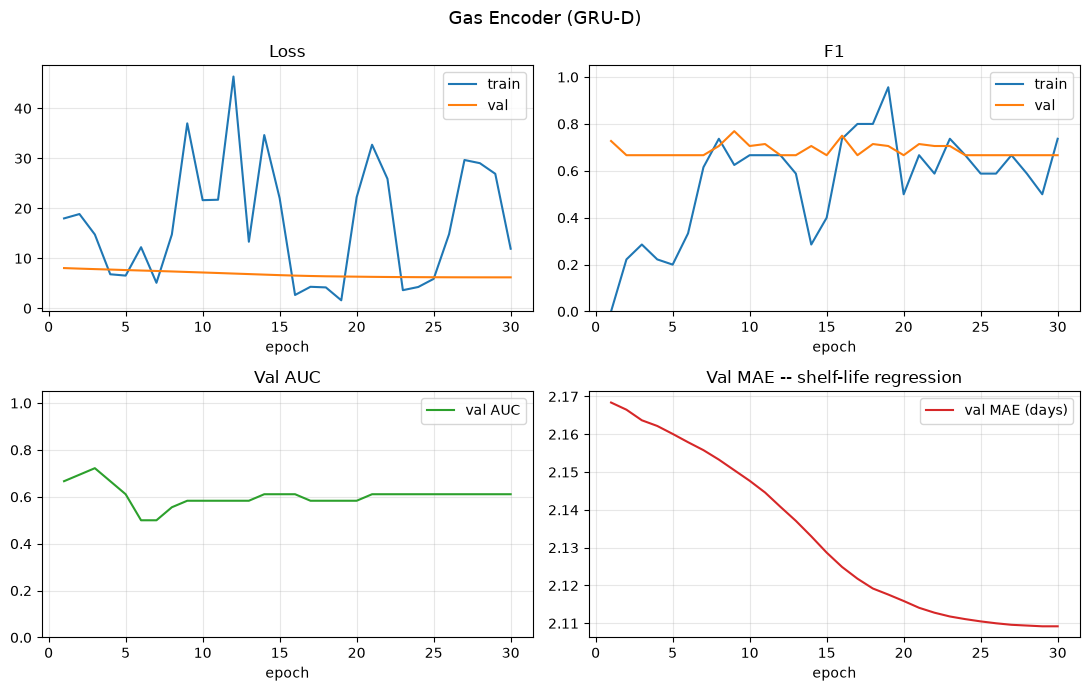

  Best epoch: 9 -- Val F1=0.7692 AUC=0.5833 MAE=2.1505


''

In [18]:
cfg_gas = get_cfg("gas")
gas_model = GasGRUDEncoder(input_dim=6, hidden_dim=64, dropout=cfg_gas["dropout"])
gas_ckpt = train_encoder(
    gas_model, cfg_gas, ENCODER_OUT / "gas_grud", encoder_type="gas",
    unfreeze_fn=None,
    train_ds=SHARED_TRAIN_DS, val_ds=SHARED_VAL_DS,
)
plot_training_curves(ENCODER_OUT / "gas_grud" / "history.json", "Gas Encoder (GRU-D)")
""

## 9. Comparison across all four unimodal encoders

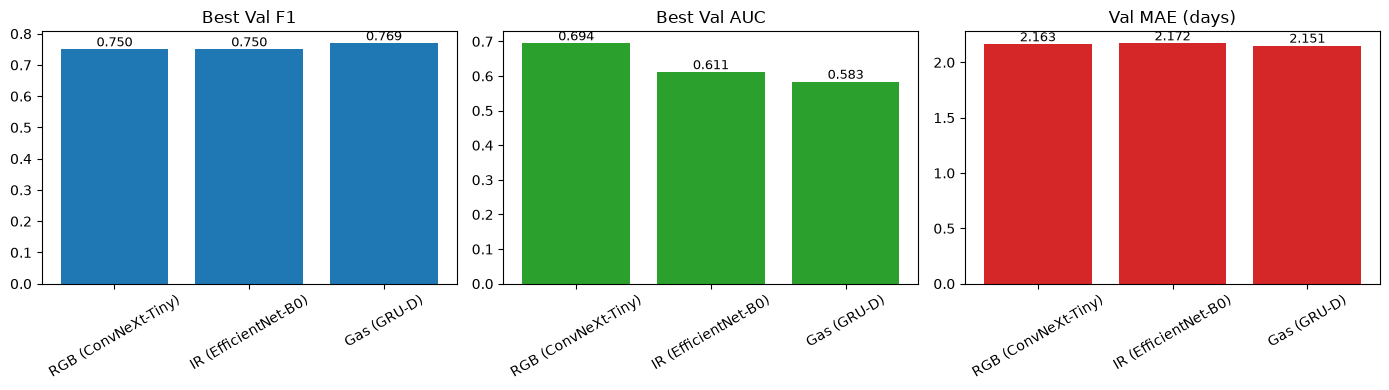


Summary:
  RGB (ConvNeXt-Tiny)      F1=0.75     AUC=0.6944   MAE=2.1634
  IR (EfficientNet-B0)     F1=0.75     AUC=0.6111   MAE=2.1718
  Gas (GRU-D)              F1=0.7692   AUC=0.5833   MAE=2.1505


In [19]:
encoder_runs = {
    "RGB (ConvNeXt-Tiny)": ENCODER_OUT / "rgb_cbam" / "history.json",
    "IR (EfficientNet-B0)": ENCODER_OUT / "ir_cbam_efficientnet" / "history.json",
    "Gas (GRU-D)": ENCODER_OUT / "gas_grud" / "history.json",
}

results = {}
for name, path in encoder_runs.items():
    if not path.exists():
        print(f"  {name}: no history.json yet at {path} -- run that cell first")
        continue
    with open(path) as f:
        history = json.load(f)["history"]
    best = max(history, key=lambda h: h["val"]["f1"])
    results[name] = {"f1": best["val"]["f1"], "auc": best["val"]["auc"], "mae": best["val"]["mae"]}

if results:
    names = list(results.keys())
    f1s  = [results[n]["f1"] for n in names]
    aucs = [results[n]["auc"] for n in names]
    maes = [results[n]["mae"] for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, vals, label, color in zip(axes, [f1s, aucs, maes],
                                       ["Best Val F1", "Best Val AUC", "Val MAE (days)"],
                                       ["tab:blue", "tab:green", "tab:red"]):
        ax.bar(names, vals, color=color)
        ax.set_title(label)
        ax.tick_params(axis="x", rotation=30)
        for i, v in enumerate(vals):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    print("\nSummary:")
    for n in names:
        r = results[n]
        print(f"  {n:<24} F1={r['f1']:<8} AUC={r['auc']:<8} MAE={r['mae']}")
else:
    print("No runs completed yet.")